In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px
import plotly.io as pio
import warnings
warnings.filterwarnings('ignore')
#Quitar y poner
#%matplotlib notebook
#%matplotlib widget

# Detección de "outliers" usando inspección visual

En esencia un valor extremo es aquel que se aleja del rango normal de los valores que tiene la Serie, bien sea porque es muy grande o muy pequeño.

El manejo de "outliers" se refiere a lo que decidimos hacer con estos valores una vez los hayamos detectado. Y esta decisión que tomemos depende de las características de la Serie.

En general podemos manejar los "outliers" de una de estas tres maneras:

1. **!No hacer nada!**: esto quiere decir que simplemente detectamos los "outliers" pero no los modificamos ni los eliminamos de la Serie de Tiempo. Por ejemplo, si tenemos una Serie de Tiempo con registros sismológicos, un temblor de tierra generaría valores extremadamente altos en la Serie de Tiempo: en este caso esos "outliers" contienen información relevante y por tanto no los eliminaríamos.

2. **Hacer recorte (*capping*)**: en este caso detectamos los "outliers" y los llevamos al rango "normal" de los valores en la Serie (por ejemplo el percentil 90).

3. **Imputación**: en este caso detectamos los "outliers", los marcamos como "NaN" y llevamos la técnica de imputación vista anteriormente para completar este dato faltante.



In [15]:
# Graficar outliers
import seaborn as sns
import matplotlib.pyplot as plt

def graficar_outliers(serie, fechas, outliers=None):
    '''Graficar la Serie de Tiempo y superponer "outliers" de
    referencia y detectados.
    
    Parámetros:
    - serie: la Serie de Tiempo (DataFrame de Pandas)
    - fechas: listado de fechas con los "outliers" conocidos
    - outliers: los outliers detectados (DataFrame de Pandas)'''
    
    # Graficar la Serie de tiempo
    ax = serie.plot(alpha=0.7)
    
    # Superponer outliers de referencia
    serie.loc[fechas].plot(ax=ax, style='bo')
    
    # Superponer outliers detectados (si existen)
    if outliers is not None:
        outliers.plot(ax=ax, style='rx')
        plt.legend(['Serie de Tiempo', 'Outliers conocidos', 'Outliers detectados']);
    else:
        plt.legend(['Serie de Tiempo', 'Outliers conocidos'])
    
    # Ajustar etiquetas    
    plt.xlabel('Fecha')
    plt.ylabel('# pasajeros')    


            valores
2024-01-01       23
2024-01-02       17
2024-01-03        6
2024-01-04       15
2024-01-05       80
2024-01-06       12
2024-01-07       19
2024-01-08       21


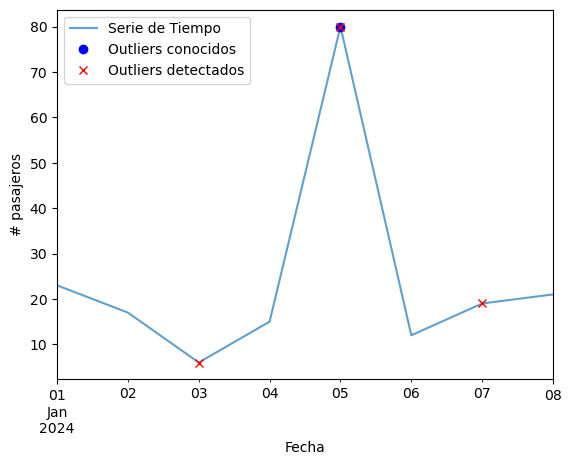

In [16]:
# Crear Serie de Tiempo
inds = pd.date_range(pd.to_datetime("2024-01-01"), pd.to_datetime("2024-01-08"))
obs = [23, 17, 6, 15, 80, 12, 19, 21]
df = pd.DataFrame(obs, index=inds, columns=["valores"])
print(df)

# Fechas con outliers conocidos
fechas = ['2024-01-05']

# Simular outliers detectados
outliers = df.iloc[[2,4,6],:]

graficar_outliers(df, fechas, outliers)

### Ejemplo
Contiene el número de pasajeros que han hecho uso del servicio de Taxis de la ciudad de Nueva York entre el 1 de julio de 2014 y el 31 de mayo de 2015.Los datos han sido tomados con frecuencia de 30 minutos y en total se tienen 10.320 registros

In [17]:

df = pd.read_csv('./data/taxis_ny.csv',
                    parse_dates = ['tiempo'],
                    index_col = ['tiempo'])
df

,obs
tiempo,
2014-07-01 00:00:00,10844
2014-07-01 00:30:00,8127
2014-07-01 01:00:00,6210
2014-07-01 01:30:00,4656
2014-07-01 02:00:00,3820
...,...
2015-01-31 21:30:00,24670
2015-01-31 22:00:00,25721
2015-01-31 22:30:00,27309


Valores extremos conocidos:

- 2014-11-01: un día antes de la maratón de Nueva York (un evento muy importante en la ciudad)
- 2014-11-27: el día de acción de gracias
- 2014-12-25: navidad
- 2014-01-01: año nuevo
- 2015-01-27: una tormenta de invierno afectó la ciudad y se prohibió la circulación de vehículos

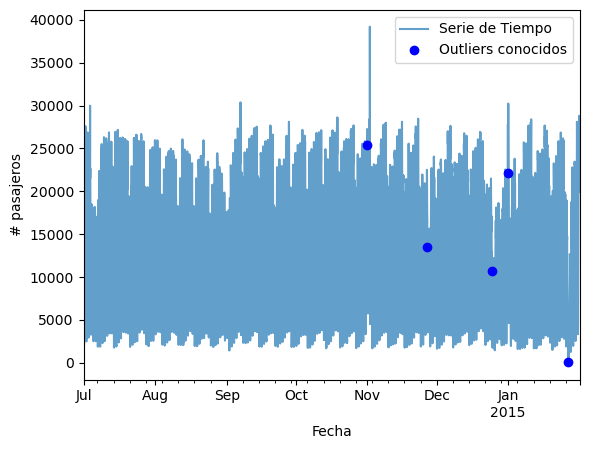

In [18]:
# fechas con outliers conocidos
fechas =  [
        "2014-11-01",
        "2014-11-27",
        "2014-12-25",
        "2015-01-01",
        "2015-01-27"
]
graficar_outliers(df, fechas)

### Detección de "outliers" mediante inspección visual

Existen esencialmente dos maneras de hacer esta detección:

- Graficando la Serie de Tiempo de forma estática o interactiva y tomando nota de los valores extremos con sus fechas correspondientes
- Usando gráficos tipo *boxplot* (vistos en detalle en la lección 6 del curso "Estadística Descriptiva": gráficos de caja (*boxplots*))

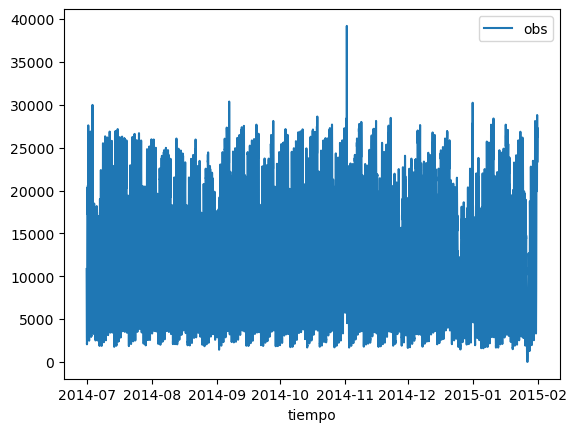

In [19]:
ax = sns.lineplot(df)

El problema en este caso es que tenemos demasiados datos (10.320) y por más que ajustemos la escala temporal y el tamaño de la gráfica, resulta difícil tener una visualización adecuada de la serie de tiempo.

Una alternativa es **remuestrear** la Serie de Tiempo para preservar la información relevante pero a la vez tener menos datos.


In [20]:
# Remuestreo a frecuencia diaria
tx_diaria = df.resample('D').mean()
tx_diaria

,obs
tiempo,
2014-07-01,15540.979167
2014-07-02,15284.166667
2014-07-03,14794.625000
2014-07-04,11511.770833
2014-07-05,11572.291667
...,...
2015-01-27,4834.541667
2015-01-28,12947.562500
2015-01-29,14686.145833


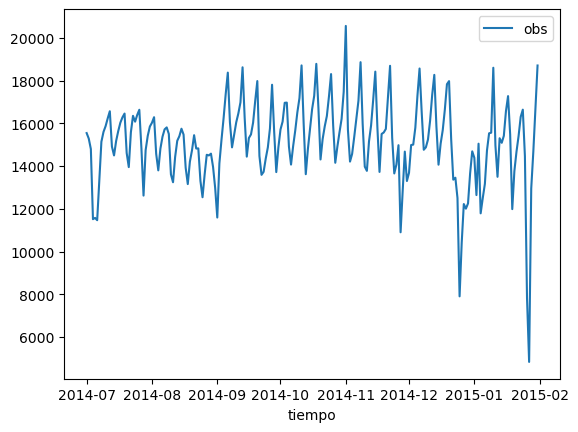

In [21]:
#Con este remuestreo hemos pasado de 10.320 registros a tan sólo 215, lo cual facilitará la visualización.
#Generemos ahora un gráfico de esta Serie de Tiempo:
ax = sns.lineplot(tx_diaria)

Recordemos que la media es un valor sensible a valores extremos, así que al hacer el remuestreo con el promedio de los datos estamos intentanto garantizar que no se pierde la información relacionada con esos valores extremos.

En efecto, al graficar la Serie anterior vemos algunos "picos" y "valles" que corresponden precisamente a esos "outliers" que queremos detectar. Sin embargo, como el gráfico es estático no resulta fácil establecer estos valores ni tampoco las fechas correspondientes.

Podemos generar un gráfico similar pero interactivo pero usando la librería Plotly:

In [22]:
pio.renderers.default = 'iframe'
pio.templates.default = "plotly_white" # Opcional: Elige un template (e.g., "ggplot2", "seaborn", "simple_white")
# Gráfico interactivo
fig = px.line(tx_diaria['obs'])
fig.show()


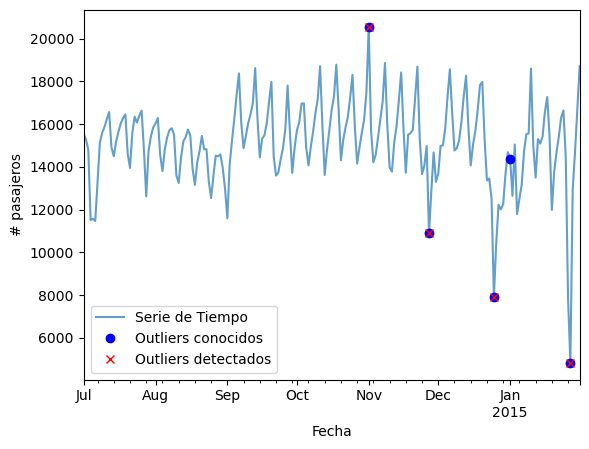

In [23]:
# Outliers detectados
fechas_outliers = ['2014-11-01', '2014-11-27', '2014-12-25', '2015-01-27']
outliers = tx_diaria.loc[fechas_outliers]

# Graficar
graficar_outliers(tx_diaria, fechas, outliers)

### Detección usando *boxplots*

Recordemos que un *boxplot* permite mostrar la distribución de los datos. Es decir que en un mismo gráfico podemos ver la mediana, el rango intercuartiles (IQR) y los "whiskers" ($\pm 1.5IQR$) así como los valores extremos.

Así que esta es la herramienta ideal para detectar estos extremos. Generemos entonces los gráficos de *boxplot* para la Serie de Tiempo original y la re-muestreada:

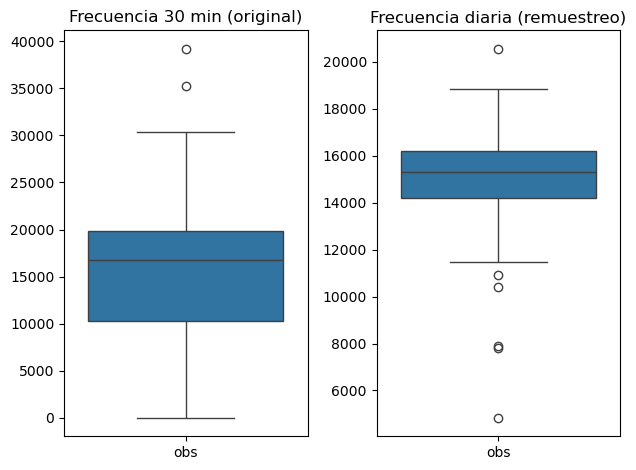

In [24]:
# Crear grilla de 1x2
fig, axs = plt.subplots(1,2)

# Boxplot 1 (serie de tiempo original)
sns.boxplot(df, ax = axs[0])
axs[0].set_title('Frecuencia 30 min (original)')

# Boxplot 2 (serie de tiempo remuestreada)
sns.boxplot(tx_diaria, ax = axs[1])
axs[1].set_title('Frecuencia diaria (remuestreo)')

fig.tight_layout()

Y vemos que el uso de la Serie remuestreada (figura derecha) permite evidenciar mejor la presencia de valores extremos.

En este caso no vemos las fechas directamente pero sí los valores extremos, ubicados por encima y por debajo de los *whiskers*.

Así que podemos usar estos *whiskers* como referencia para filtrar la Serie de Tiempo remuestreada y tomar únicamente aquellas fechas-valores por fuera de los *whiskers*:

                     obs
tiempo                  
2014-07-06  11464.270833
2014-11-01  20553.500000
2014-11-08  18857.333333
2014-11-27  10899.666667
2014-12-25   7902.125000
2014-12-26  10397.958333
2015-01-26   7818.979167
2015-01-27   4834.541667


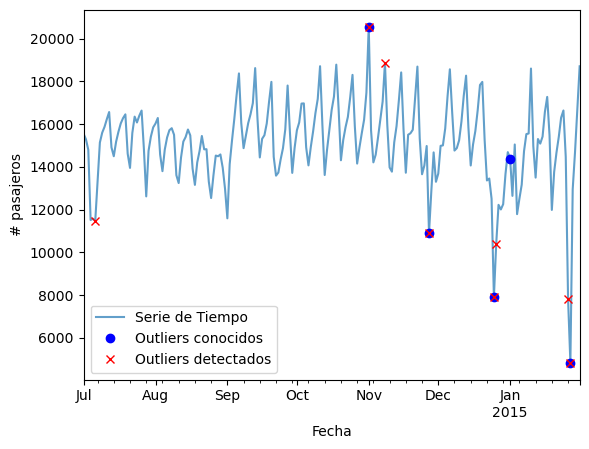

In [25]:
# Valores aproximados de los "whiskers"
w_sup = 18800
w_inf = 11500

# Outliers: preservar únicamente los valores por fuera de los whiskers
mask = (tx_diaria['obs'] <= w_inf) | (tx_diaria['obs'] >= w_sup)
outliers = tx_diaria[mask]
print(outliers)

# Graficar resultado
graficar_outliers(tx_diaria, fechas, outliers)

### Y en este caso vemos que este método sobre-estima la cantidad de *outliers* existentes.

## Aspectos a tener en cuenta

Las principales conclusiones de este método de inspección visual son las siguientes:

1. Es un método muy sencillo de implementar pero uno de los retos está en lograr visualizar correctamente la Serie o la distribución de las observaciones, especialmente cuando tenemos muchos registros.
2. En todo caso es un método subjetivo y que tiende a ser impreciso